### Import libraries

In [2]:
import scanpy as sc
import pandas as pd
from CycleVI_model import CycleVI
from sklearn.preprocessing import QuantileTransformer
import numpy as np
import torch

Surpress warnigs for legibility

In [3]:
import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings

### Download data
We download a scRNA-seq dataset from the EBI Single Cell Expression Atlars, using the ``scanpy.datasets.ebi_expression_atlas`` helper function

In [4]:
adata = sc.datasets.ebi_expression_atlas('E-CURD-84')

**Note:** to speed up the tutorial, the following code subsamples 10k cells from the dataset. Do not execute it if you want to run it on the entire dataset.

In [5]:
# For the sake of the tutorial, we subsample big datasets
sc.pp.sample(adata, n=10000)

# 1 Preprocessing
Before running the CycleVI model on the data, there are a few preprocessing steps that are needed. The model needs 3 inputs
* The gene expression count matrix.
* An initial guess for the position of each cell in the cycle (continuous variable). This is used to initialize the model during training.
* An initial guess for the classification of the cells in the cycle (categorical variable). This is used in the adversarial training on the initial epochs of training.

### The count matrix
We save the count matrix on its own anndata layer.
This needs to contain non-negative numbers. The model is build for integers but will run correctly with floats as well.

**The presence of negative values will cause the model not to run, since the support for the Negative Binomial expression model is only positive.**

In [6]:
# Add a "counts" layer that contains raw UMI counts (non-negative integers)
adata.layers["counts"] = adata.X

## The continuous initial guess
Here, we use the ``scanpy.tl.score_genes_cell_cycle`` to get initial scores for the S and G2/M phases.

In [7]:
cycle_markers = pd.read_csv('data/homo_sapiens_cc_genes.csv', index_col=0)
sc.tl.score_genes_cell_cycle(adata, s_genes=cycle_markers.loc['S','geneID'], g2m_genes=cycle_markers.loc['G2/M','geneID'])

Which we then convert to a continuous angle using ``numpy.arctan2``, and store it in the anndata

In [8]:
score_angle = np.arctan2(adata.obs["G2M_score"], adata.obs["S_score"])
score_angle = np.mod(score_angle, 2 * np.pi)  # wrap to [0, 2π]

# Store in obs
adata.obs["cycle_angle"] = score_angle

These initial guesses are needed to overcome numerical issues in the training. These issues are further diminished if we make sure that the cells are uniformly spread across the cycle. So we perform a quantile transform on our guesses.

In [9]:
def quantile_to_uniform_2pi(adata, angle_key, output_key):

    all_angles = adata.obs[angle_key].values.reshape(-1, 1)

    # Check for NaNs
    if np.isnan(all_angles).any():
        raise ValueError(f"{angle_key} contains NaNs. Please clean or impute missing values.")

    # Fit on control, transform all
    qt = QuantileTransformer(
        output_distribution='uniform',
        random_state=0,
        n_quantiles=min(len(all_angles), 1000),
        subsample=len(all_angles)
    )
    qt.fit(all_angles)
    transformed = qt.transform(all_angles).flatten()
    adata.obs[output_key] = transformed * 2 * np.pi

quantile_to_uniform_2pi(
    adata,
    angle_key="cycle_angle",
    output_key="cycle_angle_uniform",
)

The data is now ready for training.

In [10]:
print(adata)

AnnData object with n_obs × n_vars = 10000 × 21190
    obs: 'Sample Characteristic[organism]', 'Sample Characteristic Ontology Term[organism]', 'Sample Characteristic[individual]', 'Sample Characteristic Ontology Term[individual]', 'Sample Characteristic[sex]', 'Sample Characteristic Ontology Term[sex]', 'Sample Characteristic[age]', 'Sample Characteristic Ontology Term[age]', 'Sample Characteristic[developmental stage]', 'Sample Characteristic Ontology Term[developmental stage]', 'Sample Characteristic[organism part]', 'Sample Characteristic Ontology Term[organism part]', 'Sample Characteristic[disease]', 'Sample Characteristic Ontology Term[disease]', 'Sample Characteristic[metastatic site]', 'Sample Characteristic Ontology Term[metastatic site]', 'Sample Characteristic[organism status]', 'Sample Characteristic Ontology Term[organism status]', 'Sample Characteristic[sampling site]', 'Sample Characteristic Ontology Term[sampling site]', 'Sample Characteristic[cell type]', 'Sample Char

# 2 Training

We first set up the data for training. Here we indicate which ``layer`` of the anndata the count matrix is located in, as well as our continuous and categorical initial guesses.

In [11]:
CycleVI.setup_anndata(
    adata,
    layer="counts",
    cycle_initiation_angle_key="cycle_angle_uniform",
    cycle_initiation_label_key="phase"
)

And we initialize the model

In [12]:
model = CycleVI(adata, n_latent=10, cycle_gene_mask=None)

Move model to appropriate device

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.module.to(device)
print("Model on:", next(model.module.parameters()).device)


Using device: cuda
Model on: cuda:0


### Train the model

In [14]:
model.train(
    max_epochs=400,
    train_size=0.8,
    validation_size=0.2,
    shuffle_set_split=True,
    enable_progress_bar=True,
    simple_progress_bar=False,
    batch_size=128
)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=400` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=400` reached.


Save the trained model

In [15]:
model.save("./results/Trained_CycleVI", overwrite=True)

# 3 Analyzing the results

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator, ScalarFormatter, FuncFormatter
from scipy.ndimage import gaussian_filter1d

Load the model back to the CPU for easier manipulation

In [17]:
model.module.to('cpu')
print("Model on:", next(model.module.parameters()).device)

Model on: cpu


Get the latent representation of the data

In [18]:
LATENT_KEY = "latent_space"

latent = model.get_latent_representation()
adata.obsm[LATENT_KEY] = latent
latent.shape

(10000, 10)

In [19]:
adata.obsm["Cycling_latent"], adata.obsm["Non-cycling_latent"] = latent[:, :2], latent[:, 2:]

## Obtaining the infered angles
We can obtain the cell cycle angles infered by CycleVI simply by taking the angle in relation to the origin from each cell on the first two latent dimensions.

In [20]:
# Compute angles and assign to obs
adata.obs["angle"] = np.mod(np.arctan2(latent[:, 1], latent[:, 0]), 2 * np.pi)

We can also visualize the first to dimensions of the latent space by:

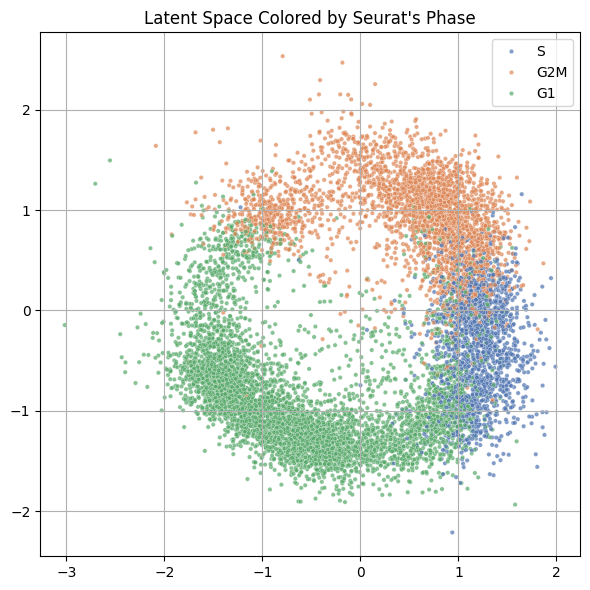

In [21]:
plt.figure(figsize=(6, 6))
sns.scatterplot(
    x=latent[:, 0],
    y=latent[:, 1],
    hue=adata.obs["phase"].values,
    palette="deep",
    s=10,
    alpha=0.7
)
plt.title("Latent Space Colored by Seurat's Phase")
plt.grid(True)
plt.tight_layout()
plt.show()

We can create and visualize an UMAP of the non-cycling latent space.

We color it by the Seurat infered phases to see if they are well mixed

In [22]:
sc.pp.neighbors(adata, use_rep="Non-cycling_latent", key_added="neighbors_Non-cycling_latent")
sc.tl.umap(adata, neighbors_key="neighbors_Non-cycling_latent", key_added="umap_Non-cycling_latent")

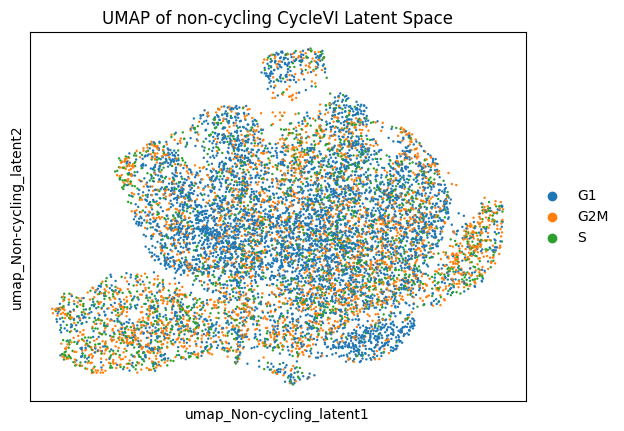

In [23]:
sc.pl.embedding(adata, basis="umap_Non-cycling_latent", color="phase", title="UMAP of non-cycling CycleVI Latent Space")


We can extract the predicted gene expression by:

In [24]:
likelihood_params = model.get_likelihood_parameters(adata=adata, give_mean=True)

Which we can use to analyze how our model fits genes along the cell cycle:

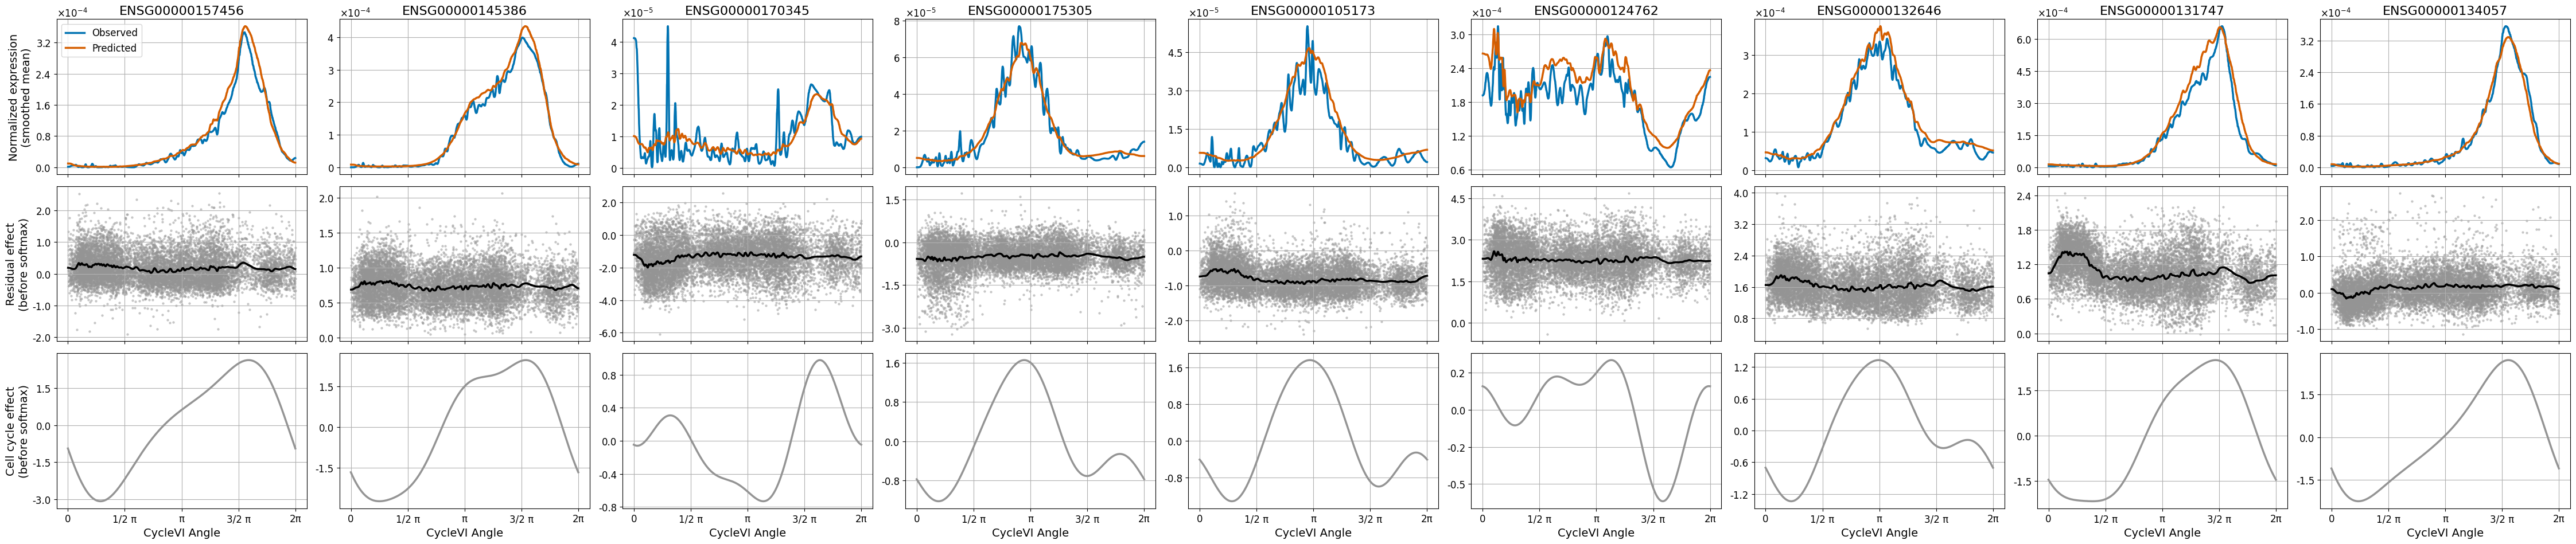

In [25]:
def plot_expression_components_grid(adata, model, likelihood_params, gene_list, smooth_sigma=50):
    palette = sns.color_palette("colorblind")
    fig, axs = plt.subplots(3, len(gene_list), figsize=(5 * len(gene_list), 10), sharex='col')

    angles_all = np.mod(adata.obs["angle"].values + np.pi, 2 * np.pi)
    library_all = adata.layers["counts"].sum(axis=1).A1
    angles_dense = np.linspace(0, 2 * np.pi, 500)

    z = torch.tensor(model.get_latent_representation(adata), device=model.device)
    z_latent = z[:, 2:]
    noncycle_logits = model.module.decoder.non_cycle_linear(
        model.module.decoder.non_cycle_fc(z_latent,[])
    )

    W_all = model.module.decoder.fourier_W.detach().cpu().numpy()
    n_fourier = W_all.shape[0] // 2
    basis = np.concatenate(
        [(-1) ** k * np.cos(k * angles_dense)[:, None] for k in range(1, n_fourier + 1)] +
        [(-1) ** k * np.sin(k * angles_dense)[:, None] for k in range(1, n_fourier + 1)],
        axis=1
    )
    cycle_effect_all = basis @ W_all

    for i, gene in enumerate(gene_list):
        if gene not in adata.var_names:
            continue
        gene_idx = adata.var_names.get_loc(gene)
        counts = adata.layers["counts"][:, gene_idx].toarray().flatten()
        obs_norm = counts / library_all
        pred_norm = likelihood_params["mean"][:, gene_idx] / library_all

        sorted_idx = np.argsort(angles_all)
        sorted_angles = angles_all[sorted_idx]
        sorted_obs = obs_norm[sorted_idx]
        sorted_pred = pred_norm[sorted_idx]
        smoothed_obs = gaussian_filter1d(sorted_obs, sigma=smooth_sigma)
        smoothed_pred = gaussian_filter1d(sorted_pred, sigma=smooth_sigma)

        axs[0, i].plot(sorted_angles, smoothed_obs, '-', color=palette[0], linewidth=2.5, label='Observed')
        axs[0, i].plot(sorted_angles, smoothed_pred, '-', color=palette[3], linewidth=2.5, label='Predicted')
        if i == 0:
            axs[0, i].set_ylabel("Normalized expression\n(smoothed mean)", fontsize=14)

        noncycle_raw = noncycle_logits[:, gene_idx].detach().cpu().numpy()
        angles_torch = np.mod(torch.atan2(z[:, 1], z[:, 0]) + np.pi, 2 * np.pi).cpu().numpy()
        sorted_idx_nc = np.argsort(angles_torch)
        sorted_angles_nc = angles_torch[sorted_idx_nc]
        sorted_nc = noncycle_raw[sorted_idx_nc]
        smoothed_nc = gaussian_filter1d(sorted_nc, sigma=smooth_sigma)

        axs[1, i].scatter(angles_torch, noncycle_raw, s=5, alpha=0.4, color=palette[7])
        axs[1, i].plot(sorted_angles_nc, smoothed_nc, '-', color='black', linewidth=2.5)
        if i == 0:
            axs[1, i].set_ylabel("Residual effect\n(before softmax)", fontsize=14)

        cycle_effect = cycle_effect_all[:, gene_idx]
        axs[2, i].plot(angles_dense, cycle_effect, color=palette[7], linewidth=2.5)
        if i == 0:
            axs[2, i].set_ylabel("Cell cycle effect\n(before softmax)", fontsize=14)
        axs[2, i].set_xlabel("CycleVI Angle", fontsize=14)

        axs[0, i].set_title(gene, fontsize=16)

        xticks = [0, 0.5 * np.pi, np.pi, 1.5 * np.pi, 2 * np.pi]
        xticklabels = ['0', '1/2 π', 'π', '3/2 π', '2π']
        for row in range(3):
            axs[row, i].set_xticks(xticks)
            axs[row, i].set_xticklabels(xticklabels, fontsize=12)
            axs[row, i].tick_params(axis='y', labelsize=12)
            axs[row, i].grid(True)

    # Y-axis formatting per row
    for row in range(3):
        for i in range(len(gene_list)):
            axs[row, i].yaxis.set_major_locator(MaxNLocator(nbins=5))

            # Row 0 = scientific notation + decimals
            if row == 0:
                sci_formatter = ScalarFormatter(useMathText=True)
                sci_formatter.set_powerlimits((-2, 2))
                axs[row, i].yaxis.set_major_formatter(sci_formatter)
                axs[row, i].yaxis.offsetText.set_fontsize(12)

            else:
                # Decimal format, one decimal place, no sci notation
                axs[row, i].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}"))

    axs[0, 0].legend(fontsize=12)
    #fig.suptitle("Gene Expression Components (Gaussian Smoothed)", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# Example usage
plot_expression_components_grid(adata, model, likelihood_params, ['ENSG00000157456', 'ENSG00000145386', 'ENSG00000170345', 'ENSG00000175305', 'ENSG00000105173', 'ENSG00000124762', 'ENSG00000132646', 'ENSG00000131747', 'ENSG00000134057'])